In [1]:
!pip install pandas scikit-learn matplotlib seaborn

In [1]:
import pandas as pd

# Load your cleaned dataset
df = pd.read_csv("arxiv_metadata_final.csv")

# Drop rows without abstracts
df = df.dropna(subset=["abstract"])
df = df.reset_index(drop=True)
df.head()

,id,title,abstract,categories,authors
0,704.0001,Calculation of prompt diphoton production cros...,A fully differential calculation in perturba...,hep-ph,C. Bal\'azs; E. L. Berger; P. M. Nadolsky; C.-...
1,704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-...",math.CO; cs.CG,Ileana Streinu and Louis Theran
2,704.0003,The evolution of the Earth-Moon system based o...,The evolution of Earth-Moon system is descri...,physics.gen-ph,Hongjun Pan
3,704.0004,A determinant of Stirling cycle numbers counts...,We show that a determinant of Stirling cycle...,math.CO,David Callan
4,704.0005,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,In this paper we show how to compute the $\L...,math.CA; math.FA,Wael Abu-Shammala and Alberto Torchinsky


In [4]:
#TF-IDF Keyword Extraction

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF matrix
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(df["abstract"])
feature_names = tfidf_vectorizer.get_feature_names_out()

# Extract top keywords per abstract
def extract_keywords(row_idx):
    row = tfidf_matrix[row_idx].toarray().flatten()
    top_indices = row.argsort()[-5:][::-1]
    return "; ".join([feature_names[i] for i in top_indices])

df["keywords"] = [extract_keywords(i) for i in range(len(df))]
df[["title", "keywords"]].head()

,title,keywords
0,Calculation of prompt diphoton production cros...,gluon; pairs; lhc; perturbative; calculation
1,Sparsity-certifying Graph Decompositions,graphs; algorithms; family; new; previous
2,The evolution of the Earth-Moon system based o...,evolution; fluid; model; dark; described
3,A determinant of Stirling cycle numbers counts...,numbers; proof; source; lattice; certain
4,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,alpha; consequence; atoms; spaces; special


In [5]:
#Topic Modeling (NMF)

In [3]:
from sklearn.decomposition import NMF

n_topics = 10  # You can change this
nmf_model = NMF(n_components=n_topics, random_state=42)
W = nmf_model.fit_transform(tfidf_matrix)
H = nmf_model.components_

# Assign dominant topic to each paper
df["topic"] = W.argmax(axis=1)
df[["title", "topic"]].head()

,title,topic
0,Calculation of prompt diphoton production cros...,6
1,Sparsity-certifying Graph Decompositions,0
2,The evolution of the Earth-Moon system based o...,6
3,A determinant of Stirling cycle numbers counts...,4
4,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,4


In [7]:
#Visualize Topic Distribution

C:\Users\91873\AppData\Local\Temp\ipykernel_19260\249727898.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts.index, y=topic_counts.values, palette="viridis")


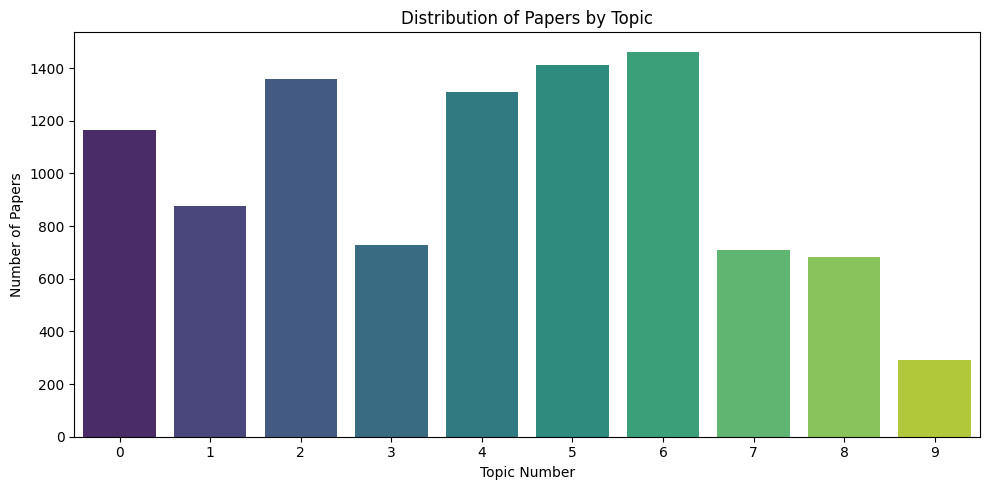

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

topic_counts = df["topic"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=topic_counts.index, y=topic_counts.values, palette="viridis")
plt.xlabel("Topic Number")
plt.ylabel("Number of Papers")
plt.title("Distribution of Papers by Topic")
plt.tight_layout()
plt.show()

In [9]:
#Save Enriched Data

In [10]:
df.to_csv("arxiv_enriched.csv", index=False)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          10000 non-null  float64
 1   title       10000 non-null  object 
 2   abstract    10000 non-null  object 
 3   categories  10000 non-null  object 
 4   authors     10000 non-null  object 
 5   keywords    10000 non-null  object 
 6   topic       10000 non-null  int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB
